In [13]:
#import all libraries in sequence of use
import pandas as pd #same
from lightgbm import LGBMRegressor 
# ref: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html#lightgbm.LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
import numpy as np
import matplotlib.pyplot as plt

In [14]:
dataset=pd.read_csv("insurance_pre.csv")

In [15]:
dataset.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges'], dtype='object')

In [16]:
# dataset.replace({"male":1,"female":0, "yes":1,"no":0}, inplace=True)- Prevented in this instant
dataset=pd.get_dummies(dataset,drop_first=True,dtype=int)
# Use get_dummies method simialr to replace() Original dataset.csv retained 

In [17]:
dataset
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0


In [18]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [19]:
indep=dataset[['age', 'sex_male', 'bmi', 'children', 'smoker_yes']]

In [20]:
indep # Sanity check

,age,sex_male,bmi,children,smoker_yes
0,19,0,27.900,0,1
1,18,1,33.770,1,0
2,28,1,33.000,3,0
3,33,1,22.705,0,0
4,32,1,28.880,0,0
...,...,...,...,...,...
1333,50,1,30.970,3,0
1334,18,0,31.920,0,0
1335,18,0,36.850,0,0
1336,21,0,25.800,0,0


In [21]:
dep=dataset[['charges']]

In [22]:
regressor=LGBMRegressor()

# Since K_Fold will do import train_test_split -disabled#
#from sklearn.model_selection import train_test_split 
#X_train,X_test,y_train,y_test=train_test_split(independent, dependent, test_size=0.30,random_state=0)
#-----------K-Fold--------------#
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

scores = cross_val_score(
    estimator=regressor, #!! Regressor assigned
    X=indep, #!! Data X and Y assigned
    y=dep.values.ravel(),#                          
    cv=kfold, #<---------------from kfold=KFold          
    scoring="r2"
)
#-----------K-Fold--------------#
print("="*60)
print("R2 Score for each fold:", scores)
print("Mean R2:", scores.mean())
print("Standard Deviation:", scores.std())
print("="*60)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train set: 1204, number of used features: 5
[LightGBM] [Info] Start training from score 13010.342228
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train set: 1204, number of used features: 5
[LightGBM] [Info] Start training from score 13468.968214
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000263 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train se

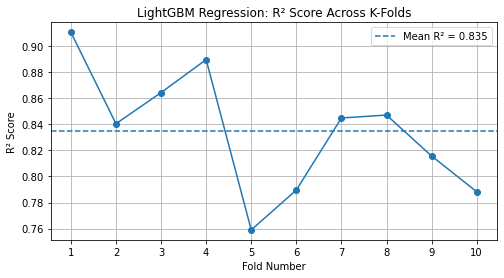

In [23]:
# R² score across K-Folds-LightGBM performs consistency across different validation subsets
folds = np.arange(1, len(scores) + 1)
plt.figure(figsize=(8, 4))
plt.plot(
    folds,
    scores,
    marker="o"
)
plt.axhline(
    y=scores.mean(),
    linestyle="--",
    label=f"Mean R² = {scores.mean():.3f}"
)
plt.xlabel("Fold Number")
plt.ylabel("R² Score")
plt.title("LightGBM Regression: R² Score Across K-Folds")
plt.xticks(folds)
plt.grid(True)
plt.legend()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train set: 1204, number of used features: 5
[LightGBM] [Info] Start training from score 13010.342228
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000335 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train set: 1204, number of used features: 5
[LightGBM] [Info] Start training from score 13468.968214
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train se

Text(0.5, 1.0, 'LightGBM Regression: Actual vs Predicted Charges')

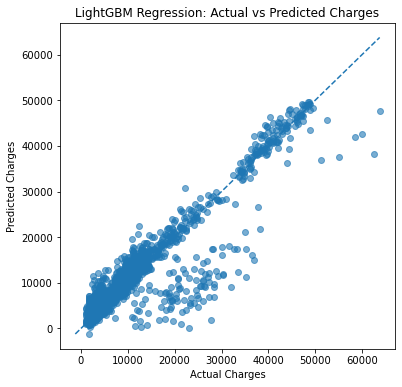

In [24]:
prediction = cross_val_predict(
    estimator=regressor,
    X=indep,
    y=dep.values.ravel(),
    cv=kfold
)
actual = dep.values.ravel()

minimum = min(actual.min(), prediction.min())
maximum = max(actual.max(), prediction.max())

plt.figure(figsize=(6, 6))

plt.scatter(actual, prediction, alpha=0.6)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("LightGBM Regression: Actual vs Predicted Charges")

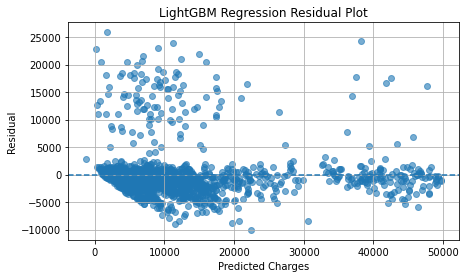

In [25]:
residual = actual - prediction

plt.figure(figsize=(7, 4))

plt.scatter(
    prediction,
    residual,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residual")
plt.title("LightGBM Regression Residual Plot")
plt.grid(True)
plt.show()

In [26]:
# Feature importance need .fit-LightGBM used most frequently or found most useful when constructing its trees.
regressor.fit(
    indep,
    dep.values.ravel()
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train set: 1338, number of used features: 5
[LightGBM] [Info] Start training from score 13270.422260


LGBMRegressor()

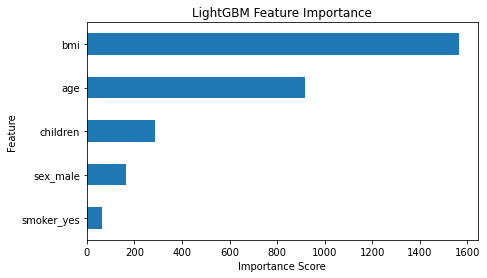

In [27]:
importance = pd.Series(
    regressor.feature_importances_,
    index=indep.columns
)

importance = importance.sort_values()

plt.figure(figsize=(7, 4))

importance.plot(kind="barh")

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance")
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train set: 1338, number of used features: 5
[LightGBM] [Info] Start training from score 13270.422260


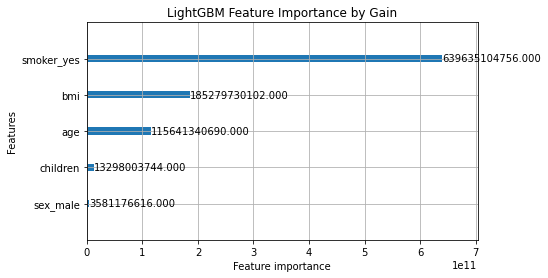

In [28]:
# Built-in LightGBM importance plot-LightGBM has its own plotting function
from lightgbm import plot_importance

regressor.fit(
    indep,
    dep.values.ravel()
)

plot_importance(
    regressor,
    importance_type="gain",
    figsize=(7, 4),
    title="LightGBM Feature Importance by Gain"
)

plt.show()